In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)
# Define the vocab and vocab_size

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

1138 pairs
['acqua', 'acque', 'aeroporti', 'aeroporto', 'aglio'] ['agua', 'aguas', 'aeropuertos', 'aeropuerto', 'ajo']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 36
Max length of spanish words:  15
Max length of italian words:  13
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[ 0.4986,  1.4003,  0.4473,  0.2108,  0.6455,  1.2749, -2.4645,  0.4096,
          1.1186,  0.0220,  0.1578,  0.4134, -0.1802,  1.2207,  2.3016, -0.7720,
         -1.8453, -0.2527, -2.0037,  0.9968, -0.5979,  1.4618, -1.3667,  1.1270,
         -0.6182,  0.6196, -1.7215,  0.4360, -1.1030, -0.6655,  1.6894, -1.2918],
        [-0.2954,  3.6484, -2.2947, -0.7663, -0.4260,  0.4159, -0.3413,  0.8037,
         -0.2974,  0.5377, -0.7591,  1.7924, -1.4603, -0.8550, -0.4260,  0.9

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[ 1.2847e+00, -6.3610e-01,  3.9337e-01, -3.6536e-01, -4.2471e-01,
           8.0172e-02,  5.5969e-01,  3.5104e-01, -6.9011e-02,  2.0183e-02,
           4.5983e-01,  4.4309e-02, -1.1899e-01, -1.2874e+00,  1.8759e-01,
          -2.4604e-01,  4.4975e-01, -4.0524e-01, -1.6259e-01, -9.2150e-02,
           1.2978e-01, -4.7006e-01,  8.1001e-02, -6.8994e-01, -1.6810e-02,
           1.8344e-01,  1.0614e-02,  6.0574e-01,  2.4898e-01,  5.8294e-02,
           4.7719e-01, -3.0202e-01, -4.2449e-01, -1.8810e-02, -4.4675e-01,
           5.9278e-02],
         [ 1.5721e-01, -7.6923e-01,  3.4398e-01, -5.2026e-01,  5.9847e-01,
          -3.9876e-01, -9.8977e-01,  4.8902e-02, -1.9065e-01,  4.3823e-02,
          -8.0611e-02,  8.3283e-02, -1.4856e-01,  8.9875e-01,  9.3909e-01,
           3.1984e-01,  5.4872e-01, -7.4260e-02,  5.6152e-01, -2.8720e-01,
          -3.9007e-01,  1.6517e-01, -3.8929e-01, -9.3124e-01, -9.9667e-01,
           3.3232e-01,  1.3564e-01, -6.6768e-01, -7.8575e-01,  4.6113e-01,
 

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1152,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1188,
 'criterion': 0,
 'TOTAL': 91428}

# Fit the model

In [5]:

# define and train two models, a lighter and a heabier one
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01)
trafo2 = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01)

print('trafo1')
print(trafo1.count_parameters_by_module())

print('trafo2')
print(trafo2.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo1')
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2')
trafo2.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo1
{'embed': 576, 'pos_encoding': 0, 'encoder': 1286, 'decoder': 1468, 'exit_linear_projection': 612, 'criterion': 0, 'TOTAL': 3942}
trafo2
{'embed': 1152, 'pos_encoding': 0, 'encoder': 50944, 'decoder': 84864, 'exit_linear_projection': 1188, 'criterion': 0, 'TOTAL': 138148}
train trafo1
Epoch  0 / 500  loss =  3.723932981491089  loss_eval =  3.711189031600952
Epoch  100 / 500  loss =  1.6637229919433594  loss_eval =  1.8447729349136353
Epoch  200 / 500  loss =  1.3992805480957031  loss_eval =  1.6785229444503784
Epoch  300 / 500  loss =  1.283447027206421  loss_eval =  1.612094521522522
Epoch  400 / 500  loss =  1.2401841878890991  loss_eval =  1.5878914594650269
train trafo2
Epoch  0 / 500  loss =  3.727349042892456  loss_eval =  3.7092792987823486
Epoch  100 / 500  loss =  0.4734146296977997  loss_eval =  1.118739366531372
Epoch  200 / 500  loss =  0.006373249925673008  loss_eval =  1.5735061168670654
Epoch  300 / 500  loss =  0.0037701481487601995  loss_eval =  1.67459785938262

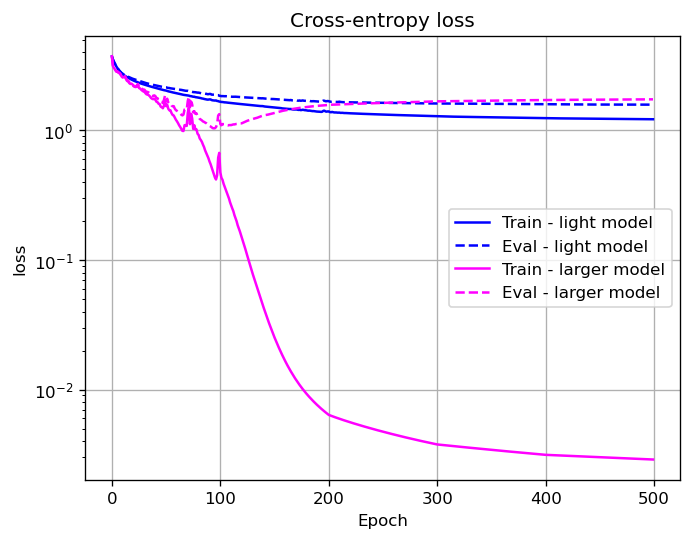

In [6]:
plt.figure(dpi = 120)
plt.title('Cross-entropy loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'blue', label = 'Train - light model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'blue', label = 'Eval - light model')
plt.semilogy(trafo2.epochs, trafo2.losses, color = 'magenta', label = 'Train - larger model')
plt.semilogy(trafo2.epochs, trafo2.losses_eval, '--', color = 'magenta', label = 'Eval - larger model')
plt.legend()
plt.show()

def translate_string(word, model):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = model.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [9]:
italian_words = ["gatto", "nave", "croci", "croce", "dito", "stretta", "stretti", "stretto", "strette", "pensate", "lasagna"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]

print("Words in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output larger model':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_2[k]:<20}")

italian_words = ["lutti", "andato", "ottone", "castoro"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]

print("Words not in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output larger model':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_2[k]:<20}")

Words in training dataset
Italian         | output light model   | output larger model 
-----------------------------------------------------------
gatto           | ganañas              | gato                
nave            | navas                | nave                
croci           | crres                | cruces              
croce           | crrtas               | cruz                
dito            | derto                | dedo                
stretta         | esto                 | estar               
stretti         | especues             | estrechos           
stretto         | estras               | estrecho            
strette         | estras               | estrechas           
pensate         | pintalos             | pensada             
lasagna         | labajada             | lasaña              
Words not in training dataset
Italian         | output light model   | output larger model 
-----------------------------------------------------------
lutti           | 

# basically, overfitting
works fine on training dataset but not very well on random words. especially with large model. in some cases the lighter model gives correct results for words not in training dataset (such as lutti - luchos). Note that the Spanish must does not have to exist in reality! It is only a hypothetical words obtained by applying the phonetical correspoendence between the two languages

same phenomenon if I change the number of layers n_layers

need bigger dataset

**regularization: try dropoff and weight decay**